# 05 - Final Insights And Recommendations

## Price Intelligence Platform

Ce notebook transforme les résultats des phases précédentes en conclusions finales, recommandations business et éléments prêts pour le rapport ou la présentation.

**Objectifs :**

- consolider les résultats de Data Understanding, Cleaning, EDA et Statistical Tests,
- produire une synthèse exécutive,
- formuler des insights business,
- documenter les limites de l'analyse,
- générer automatiquement un rapport Markdown dans `reports/`.

## 1. Positionnement du rôle Data Analyst

Dans ce projet, le rôle Data Analyst consiste à transformer les données e-commerce disponibles en insights exploitables.

Le périmètre couvre :

- compréhension des données,
- nettoyage et préparation analytique,
- analyse exploratoire,
- tests statistiques,
- interprétation et recommandations.

Les composants Bigtable, Airflow, NiFi, scraping et infrastructure sont utilisés comme sources ou contexte, mais ne constituent pas le cœur de ce livrable Data Analyst.

## 2. Imports et configuration

In [1]:
from pathlib import Path
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display, Image

DATA_ANALYSIS_DIR = Path(r"C:\\Users\\Admin\\Desktop\\data-analysis")
OUTPUTS_DIR = DATA_ANALYSIS_DIR / "outputs"
OUTPUT_TABLES = OUTPUTS_DIR / "tables"
OUTPUT_FIGURES = OUTPUTS_DIR / "figures"
OUTPUT_CLEANED = OUTPUTS_DIR / "cleaned_data"
REPORTS_DIR = DATA_ANALYSIS_DIR / "reports"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

AUTO_SAVE = True

print("Dossier de travail :", DATA_ANALYSIS_DIR)
print("Dossier des tableaux :", OUTPUT_TABLES)
print("Dossier des figures :", OUTPUT_FIGURES)
print("Dossier des rapports :", REPORTS_DIR)

Dossier de travail : C:\Users\Admin\Desktop\data-analysis
Dossier des tableaux : C:\Users\Admin\Desktop\data-analysis\outputs\tables
Dossier des figures : C:\Users\Admin\Desktop\data-analysis\outputs\figures
Dossier des rapports : C:\Users\Admin\Desktop\data-analysis\reports


## 3. Fonctions utilitaires

In [2]:

EXPECTED_MIN_CLEAN_ROWS = 4000
EXPECTED_MIN_STORES = 3
EXPECTED_MIN_CATEGORIES = 6
EXPECTED_STORE = "sport-direct"
EXPECTED_MIN_SCRAPE_DATE = pd.Timestamp("2026-05-19")

def assert_current_clean_dataset(df, path):
    stores = set(df.get("store", pd.Series(dtype="object")).dropna().astype(str).str.lower())
    categories = set(df.get("category", pd.Series(dtype="object")).dropna().astype(str).str.lower())
    scraped_at = pd.to_datetime(df.get("scraped_at", pd.Series(dtype="object")), errors="coerce")
    max_scrape = scraped_at.max()

    if len(df) < EXPECTED_MIN_CLEAN_ROWS:
        raise ValueError(
            f"Dataset nettoye trop petit: {len(df)} lignes seulement dans {path}. "
            "Relance 02_data_cleaning.ipynb apres BigQuery live."
        )
    if len(stores) < EXPECTED_MIN_STORES:
        raise ValueError(
            f"Dataset incomplet: seulement {len(stores)} plateformes dans {path}. "
            "Relance 02_data_cleaning.ipynb avec BigQuery live."
        )
    if EXPECTED_STORE not in stores:
        raise ValueError(
            f"Dataset nettoye stale: store {EXPECTED_STORE} absent dans {path}. "
            "Relance 02_data_cleaning.ipynb."
        )
    if len(categories) < EXPECTED_MIN_CATEGORIES:
        raise ValueError(
            f"Dataset incomplet: seulement {len(categories)} categories dans {path}. "
            "Verifie la table BigQuery et relance le nettoyage."
        )
    if pd.isna(max_scrape) or max_scrape < EXPECTED_MIN_SCRAPE_DATE:
        raise ValueError(
            f"Dataset nettoye stale: derniere date scrape = {max_scrape}. "
            "Relance 01 puis 02 avec BigQuery live."
        )


In [3]:
def read_table(filename, required=False):
    path = OUTPUT_TABLES / filename
    if path.exists():
        return pd.read_csv(path)
    if required:
        raise FileNotFoundError(f"Table obligatoire introuvable : {path}")
    print(f"Table optionnelle introuvable : {filename}")
    return pd.DataFrame()

def read_clean_dataset():
    no_outliers = OUTPUT_CLEANED / "02_clean_prices_no_outliers.csv"
    with_flags = OUTPUT_CLEANED / "02_clean_prices_with_outlier_flag.csv"
    if no_outliers.exists():
        df_loaded = pd.read_csv(no_outliers)
        assert_current_clean_dataset(df_loaded, no_outliers)
        return df_loaded, no_outliers
    if with_flags.exists():
        df_loaded = pd.read_csv(with_flags)
        assert_current_clean_dataset(df_loaded, with_flags)
        return df_loaded, with_flags
    raise FileNotFoundError("Aucun dataset nettoye trouve. Execute 02_data_cleaning.ipynb avec BigQuery live.")

def fmt_number(value):
    try:
        return f"{float(value):,.2f}"
    except Exception:
        return str(value)

def show_figure(filename, title=None):
    path = OUTPUT_FIGURES / filename
    if path.exists():
        if title:
            display(Markdown(f"### {title}"))
        display(Image(filename=str(path)))
    else:
        print(f"Figure introuvable : {filename}")


## 4. Chargement des résultats précédents

In [4]:
df, dataset_path = read_clean_dataset()

global_kpis = read_table("03_global_kpis.csv")
cleaning_audit = read_table("02_cleaning_audit.csv")
outlier_comparison = read_table("02_outlier_comparison.csv")
price_by_store = read_table("03_price_by_store.csv")
price_by_category = read_table("03_price_by_category.csv")
discount_by_store = read_table("03_discount_by_store.csv")
discount_by_category = read_table("03_discount_by_category.csv")
rating_by_store = read_table("03_rating_by_store.csv")
eda_insights = read_table("03_eda_insights.csv")
statistical_tests = read_table("04_main_statistical_tests.csv")
pairwise_store_tests = read_table("04_pairwise_store_tests.csv")
correlation_tests = read_table("04_correlation_tests.csv")
regression_summary = read_table("04_regression_summary.csv")
statistical_insights = read_table("04_statistical_insights.csv")

print("Dataset final utilisé :", dataset_path)
print("Nombre de lignes :", len(df))
print("Nombre de plateformes :", df['store'].nunique())
print("Nombre de catégories :", df['category'].nunique())

df.head()

Dataset final utilisé : C:\Users\Admin\Desktop\data-analysis\outputs\cleaned_data\02_clean_prices_no_outliers.csv
Nombre de lignes : 4890
Nombre de plateformes : 3
Nombre de catégories : 7


,store,category,name,price,price_before_discount,discount,stars,availability,scraped_at,scraped_date,is_price_outlier
0,ebay,unknown,Nutricost Whey Protein Isolate (Vanilla) 5LBS ...,915.570,NaN,NaN,5.000,in stock,2026-05-15 22:09:41.674252,2026-05-15,False
1,ebay,gym,Nutricost Whey Protein Isolate (Vanilla) 5LBS ...,915.570,NaN,NaN,5.000,in stock,2026-05-16 13:11:38.818884,2026-05-16,False
2,ebay,unknown,Nutricost Whey Protein Isolate (Chocolate) 2LB...,462.310,NaN,NaN,0.000,in stock,2026-05-15 22:09:41.863273,2026-05-15,False
3,ebay,gym,Nutricost Whey Protein Isolate (Chocolate) 2LB...,462.310,NaN,NaN,0.000,in stock,2026-05-16 13:11:38.849310,2026-05-16,False
4,ebay,unknown,Nutricost Whey Protein Isolate (Unflavored) 5L...,915.570,NaN,NaN,0.000,in stock,2026-05-15 22:09:41.906073,2026-05-15,False


## 5. Executive Summary

In [5]:
products_count = len(df)
stores_count = df["store"].nunique()
categories_count = df["category"].nunique()
median_price = df["price"].median()
avg_price = df["price"].mean()

cheapest_store = price_by_store.sort_values("prix_median").iloc[0] if not price_by_store.empty else None
most_expensive_store = price_by_store.sort_values("prix_median", ascending=False).iloc[0] if not price_by_store.empty else None
most_expensive_category = price_by_category.sort_values("prix_median", ascending=False).iloc[0] if not price_by_category.empty else None
best_discount_store = discount_by_store.sort_values("remise_mediane", ascending=False).iloc[0] if not discount_by_store.empty else None

summary_lines = [
    f"L'analyse finale porte sur {products_count:,} produits nettoyés, répartis sur {stores_count} plateformes et {categories_count} catégories.",
    f"Le prix médian global est de {median_price:.2f}, tandis que le prix moyen est de {avg_price:.2f}.",
]

if cheapest_store is not None:
    summary_lines.append(f"La plateforme la moins chère selon le prix médian est {cheapest_store['plateforme']} ({cheapest_store['prix_median']:.2f}).")
if most_expensive_store is not None:
    summary_lines.append(f"La plateforme la plus chère selon le prix médian est {most_expensive_store['plateforme']} ({most_expensive_store['prix_median']:.2f}).")
if most_expensive_category is not None:
    summary_lines.append(f"La catégorie la plus chère selon le prix médian est {most_expensive_category['categorie']} ({most_expensive_category['prix_median']:.2f}).")
if best_discount_store is not None:
    summary_lines.append(f"La plateforme avec la remise médiane la plus élevée est {best_discount_store['plateforme']} ({best_discount_store['remise_mediane']:.2f}%).")

for line in summary_lines:
    print("-", line)

executive_summary_df = pd.DataFrame({"summary_point": summary_lines})
executive_summary_df

- L'analyse finale porte sur 4,890 produits nettoyés, répartis sur 3 plateformes et 7 catégories.
- Le prix médian global est de 312.50, tandis que le prix moyen est de 423.08.
- La plateforme la moins chère selon le prix médian est jumia (180.00).
- La plateforme la plus chère selon le prix médian est ebay (342.06).
- La catégorie la plus chère selon le prix médian est volleyball (371.02).
- La plateforme avec la remise médiane la plus élevée est sport-direct (45.00%).


,summary_point
0,"L'analyse finale porte sur 4,890 produits nett..."
1,"Le prix médian global est de 312.50, tandis qu..."
2,La plateforme la moins chère selon le prix méd...
3,La plateforme la plus chère selon le prix médi...
4,La catégorie la plus chère selon le prix média...
5,La plateforme avec la remise médiane la plus é...


## 6. Résultats clés - Qualité et nettoyage des données

In [6]:
print("Audit du nettoyage :")
display(cleaning_audit)

print("Impact des outliers :")
display(outlier_comparison)

Audit du nettoyage :


,metric,value
0,lignes_chargees_apres_validation_base,"23,166.000"
1,lignes_apres_filtres_obligatoires,"23,166.000"
2,doublons_supprimes,"17,848.000"
3,outliers_detectes,428.000
4,lignes_dataset_final_avec_outliers_marques,"5,318.000"
5,lignes_dataset_final_sans_outliers,"4,890.000"
6,prix_max_avec_outliers,"35,612.500"
7,prix_max_sans_outliers,"1,563.250"


Impact des outliers :


,dataset,nombre_lignes,prix_moyen,prix_median,prix_maximum,ecart_type
0,avec_outliers,5318,627.782,342.060,"35,612.500","1,040.872"
1,sans_outliers,4890,423.075,312.500,"1,563.250",354.163


**Interprétation attendue :**

Les données contiennent des prix extrêmes qui peuvent fortement influencer la moyenne. Pour cette raison, les analyses finales utilisent principalement la médiane et une version du dataset sans outliers extrêmes.

## 7. Résultats clés - Prix par plateforme

In [7]:
price_by_store

,plateforme,nombre_produits,prix_moyen,prix_median,prix_minimum,prix_maximum,ecart_type
0,jumia,584,241.419,179.995,9.000,"1,499.000",226.120
1,sport-direct,671,411.609,306.250,31.250,"1,562.500",341.482
2,ebay,3635,454.377,342.060,9.160,"1,563.250",364.334


### Prix par plateforme

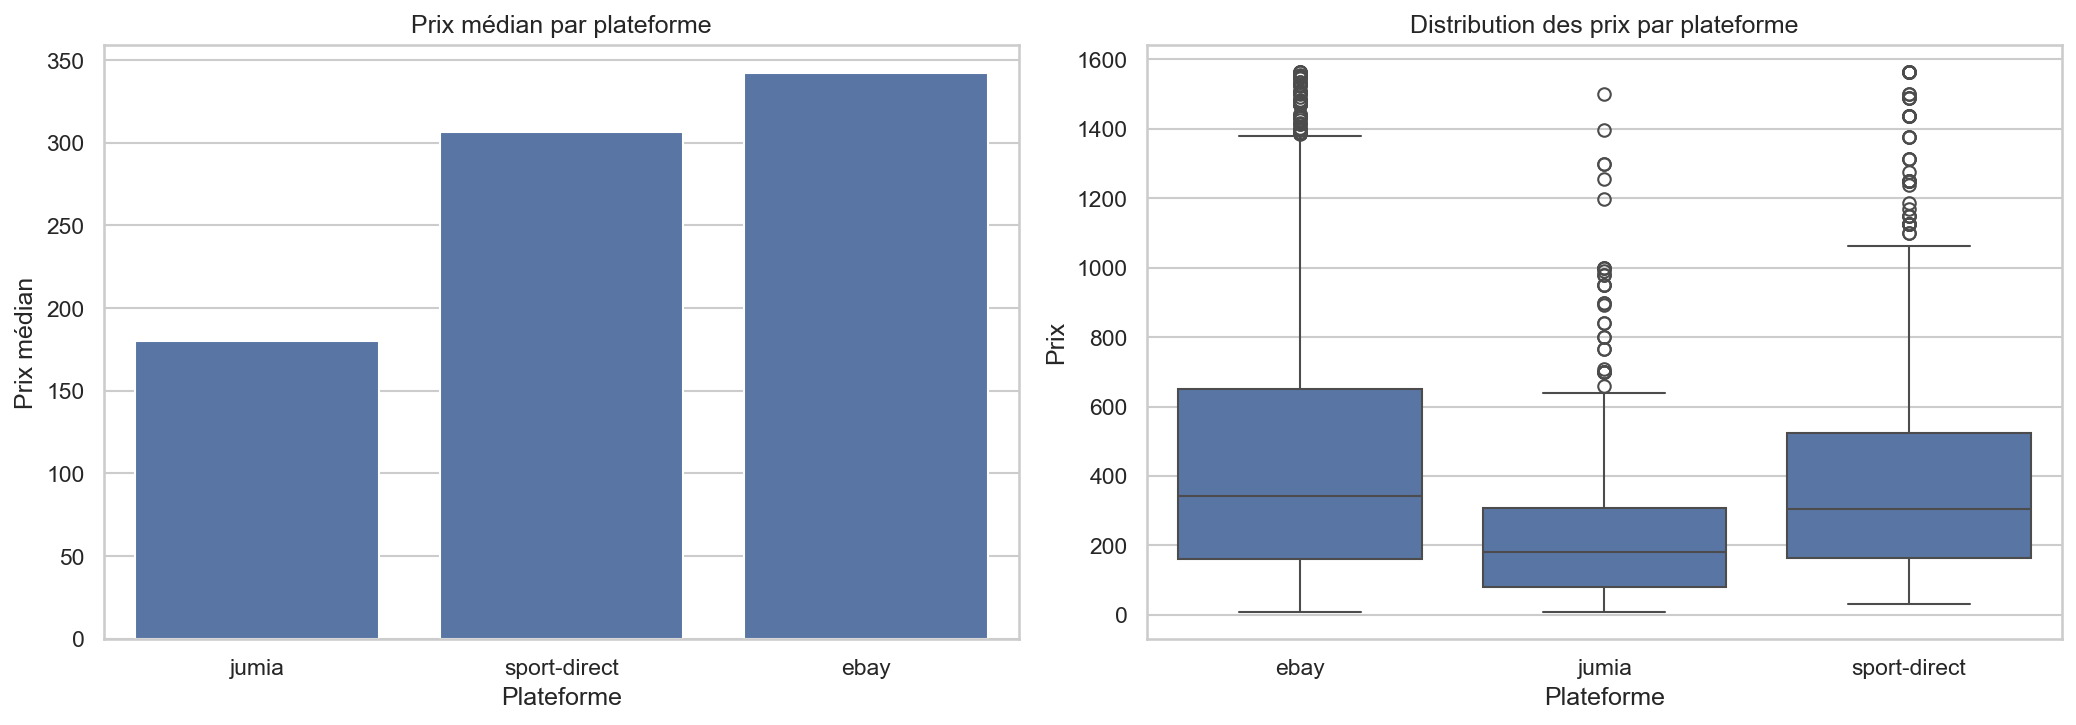

In [8]:
show_figure("03_prix_par_plateforme.png", "Prix par plateforme")

## 8. Résultats clés - Prix par catégorie

In [9]:
price_by_category

,categorie,nombre_produits,prix_moyen,prix_median,prix_minimum,prix_maximum,ecart_type
0,volleyball,319,493.042,371.020,9.160,"1,500.000",368.538
1,football,835,487.815,369.910,9.160,"1,563.250",367.824
2,unknown,1191,463.875,369.540,9.160,"1,563.250",364.750
3,racket-sports,328,508.408,321.625,18.790,"1,562.500",453.045
4,basketball,658,402.350,284.945,9.160,"1,563.250",341.009
5,gym,716,322.961,277.410,53.740,"1,435.230",243.586
6,combat-sports,843,342.838,229.000,9.000,"1,563.250",328.072


### Prix médian par catégorie

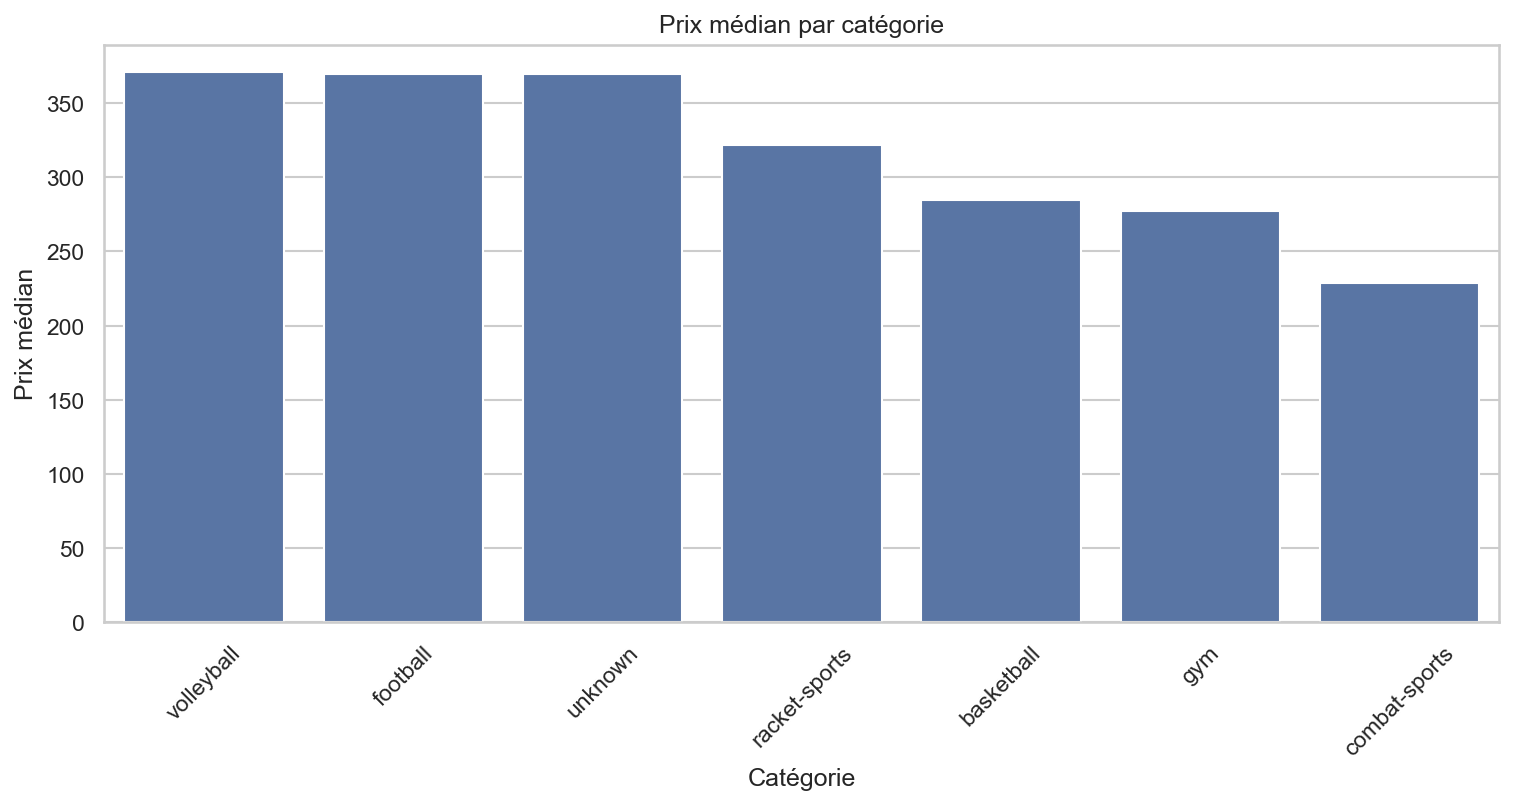

### Prix médian par plateforme et catégorie

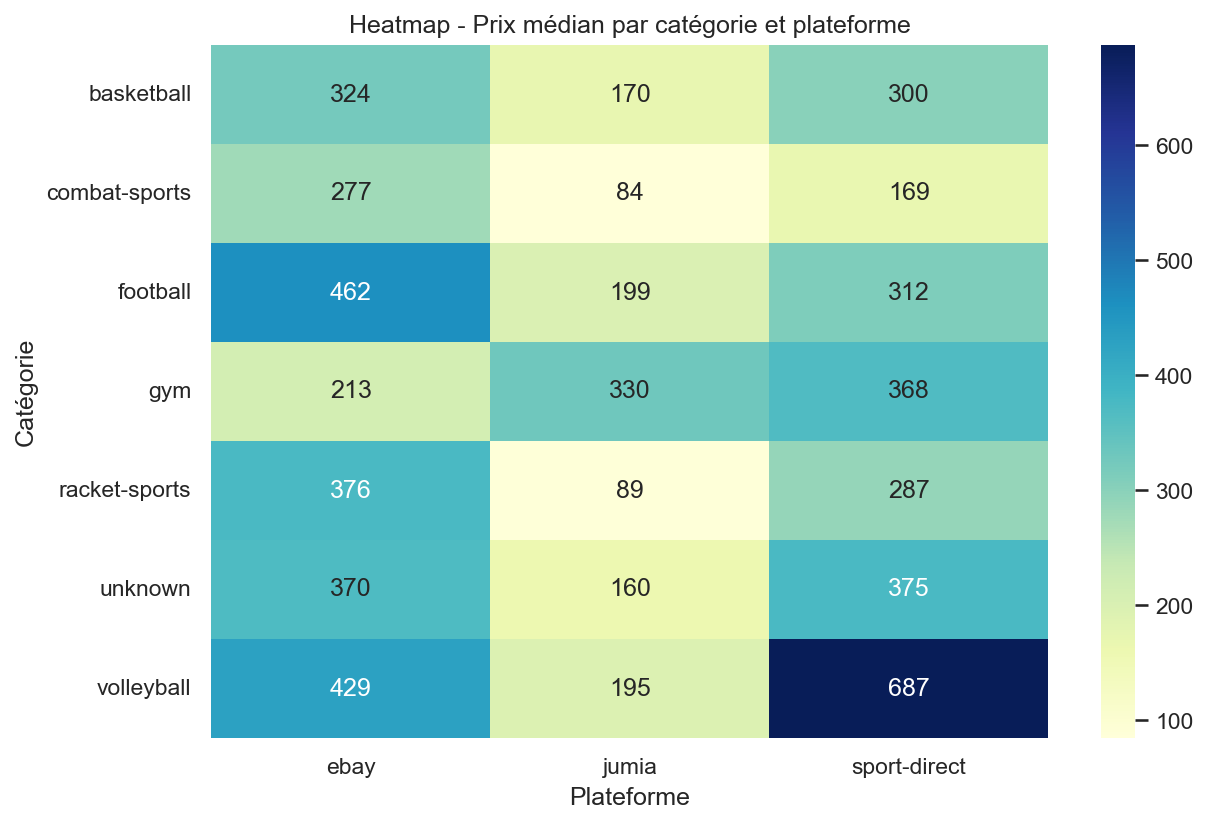

In [10]:
show_figure("03_prix_median_par_categorie.png", "Prix médian par catégorie")
show_figure("03_heatmap_prix_median_store_categorie.png", "Prix médian par plateforme et catégorie")

## 9. Résultats clés - Remises et notes clients

In [11]:
print("Remises par plateforme :")
display(discount_by_store)

print("Remises par catégorie :")
display(discount_by_category)

print("Notes clients par plateforme :")
display(rating_by_store)

Remises par plateforme :


,plateforme,nombre_produits_avec_remise,remise_moyenne,remise_mediane,remise_maximum
0,jumia,441,35.256,34.000,90.000
1,sport-direct,422,44.017,45.000,85.000


Remises par catégorie :


,categorie,nombre_produits_avec_remise,remise_moyenne,remise_mediane,remise_maximum
0,basketball,187,49.668,50.000,85.000
1,combat-sports,185,40.735,40.000,90.000
2,football,195,37.190,35.000,76.000
3,gym,126,24.087,21.000,71.000
4,racket-sports,59,39.932,45.000,80.000
5,unknown,58,43.483,45.000,75.000
6,volleyball,53,40.264,38.000,75.000


Notes clients par plateforme :


,plateforme,nombre_produits_notes,note_moyenne,note_mediane
0,ebay,3635,0.245,0.000
1,jumia,584,1.303,0.000
2,sport-direct,671,0.000,0.000


### Analyse des remises

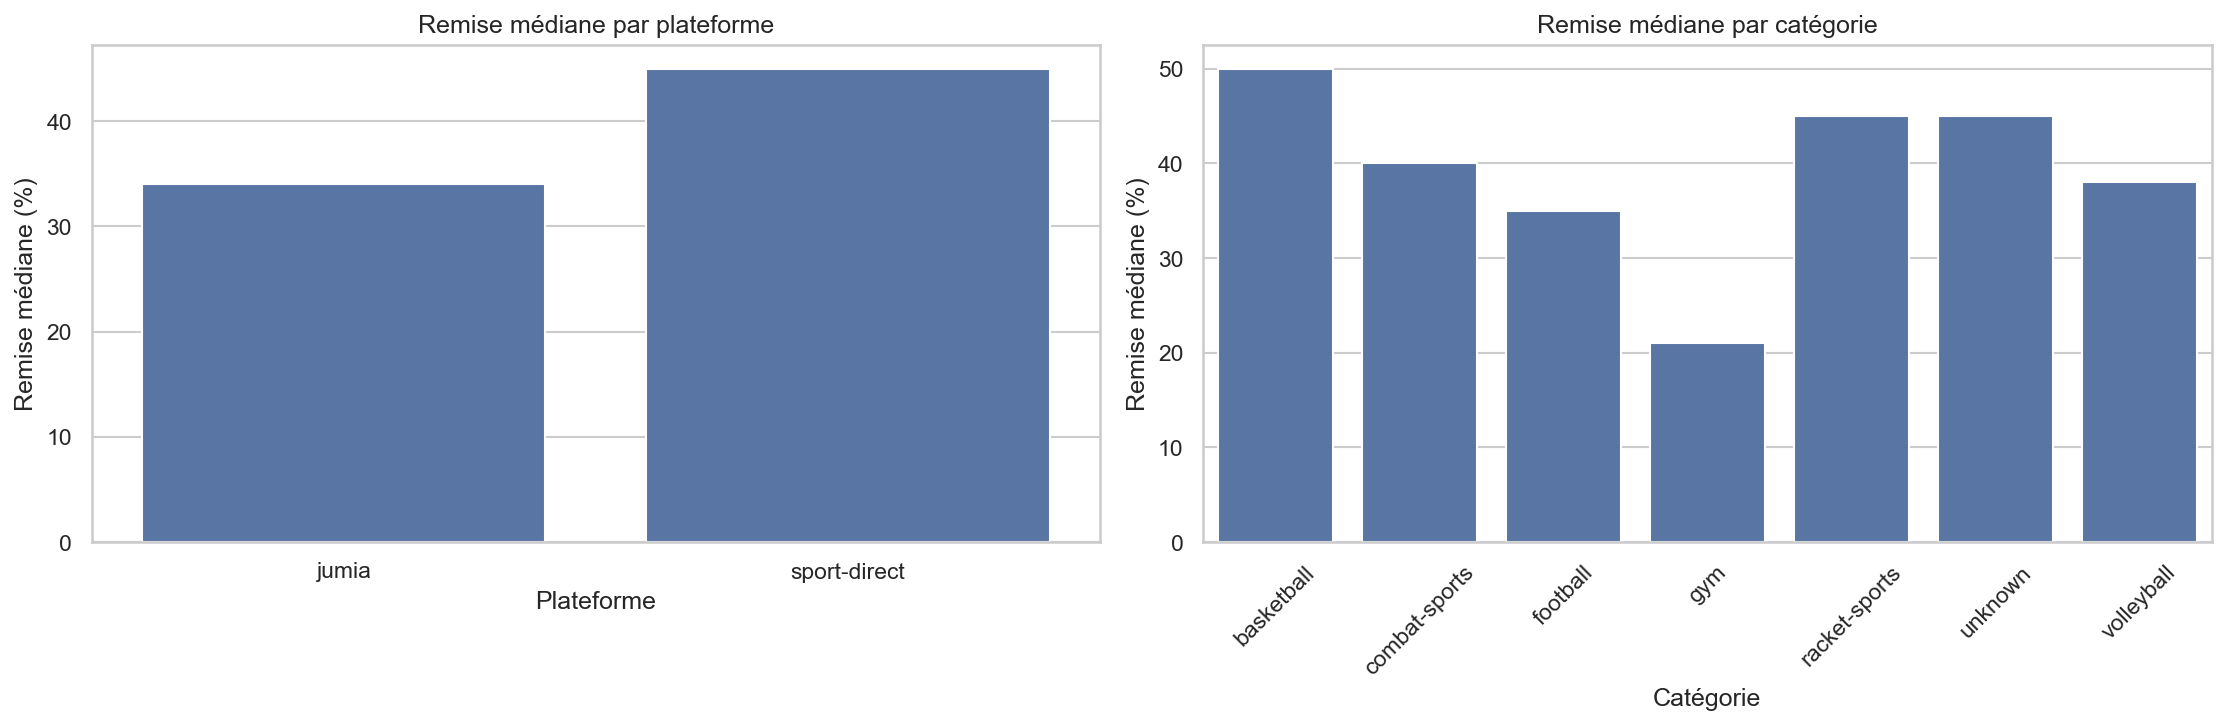

### Relation entre note client et prix

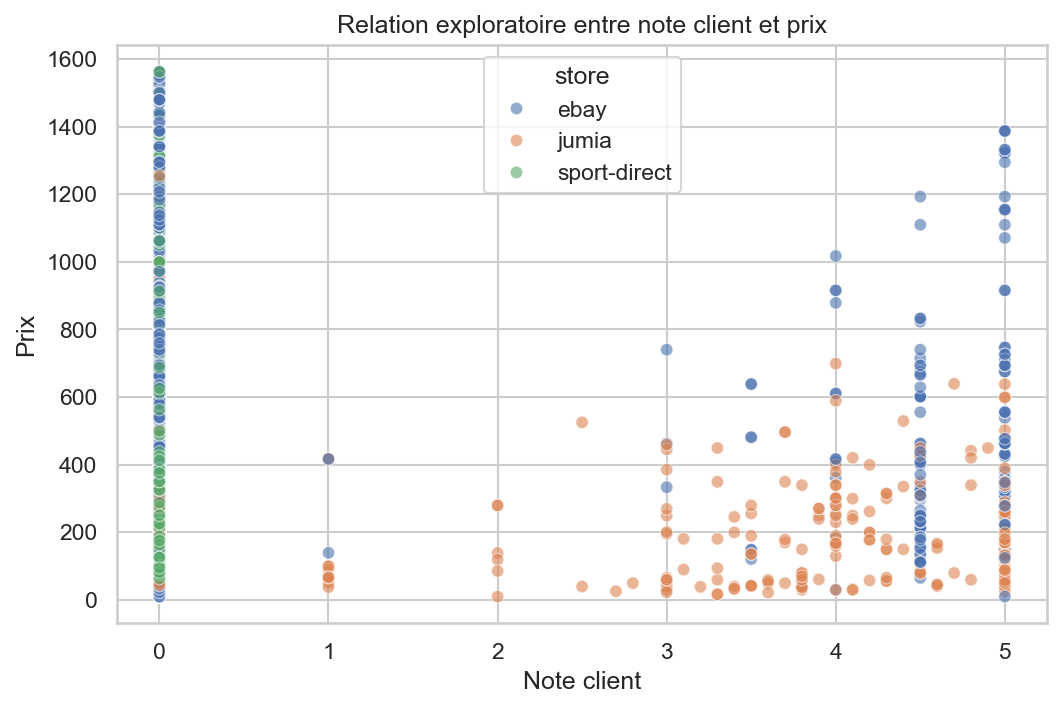

In [12]:
show_figure("03_analyse_remises.png", "Analyse des remises")
show_figure("03_relation_note_prix.png", "Relation entre note client et prix")

## 10. Résultats statistiques

In [13]:
if statistical_tests.empty:
    print("Les résultats statistiques 04 ne sont pas encore disponibles. Exécute 04_statistical_tests.ipynb puis relance ce notebook.")
else:
    display(statistical_tests)

if not pairwise_store_tests.empty:
    print("Comparaisons deux à deux entre plateformes :")
    display(pairwise_store_tests)

if not correlation_tests.empty:
    print("Tests de corrélation :")
    display(correlation_tests)

if not regression_summary.empty:
    print("Résumé de la régression :")
    display(regression_summary)

,hypothese,test,statistic,p_value,significatif,interpretation
0,Différence de prix entre plateformes,ANOVA,94.879,0.000,True,Différence significative
1,Différence de prix entre plateformes,Kruskal-Wallis,229.951,0.000,True,Différence significative
2,Différence de prix entre catégories,ANOVA,30.738,0.000,True,Différence significative
3,Différence de prix entre catégories,Kruskal-Wallis,173.529,0.000,True,Différence significative


Comparaisons deux à deux entre plateformes :


,groupe_a,groupe_b,median_a,median_b,test,statistic,p_value,p_value_bonferroni,significatif
0,ebay,jumia,342.060,179.995,Mann-Whitney U,"1,471,325.500",0.000,0.000,True
1,ebay,sport-direct,342.060,306.250,Mann-Whitney U,"1,282,025.500",0.035,0.104,False
2,jumia,sport-direct,179.995,306.250,Mann-Whitney U,"124,453.500",0.000,0.000,True


Tests de corrélation :


,variables,test,n,correlation,p_value,significatif
0,price vs discount,Spearman,863,-0.303,0.000,True
1,price vs stars,Spearman,4890,-0.073,0.000,True


Résumé de la régression :


,metric,value
0,r_squared,0.083
1,adj_r_squared,0.082
2,f_pvalue,0.000
3,n_observations,"4,890.000"


In [14]:
if not statistical_insights.empty and "insight" in statistical_insights.columns:
    print("Insights statistiques :")
    for insight in statistical_insights["insight"].dropna().tolist():
        print("-", insight)
else:
    print("Aucune synthèse statistique sauvegardée pour le moment.")

Insights statistiques :
- Les prix diffèrent significativement entre plateformes selon le test de Kruskal-Wallis.
- Les prix diffèrent significativement entre catégories selon le test de Kruskal-Wallis.
- Nombre de comparaisons significatives entre plateformes après correction Bonferroni : 2.
- La relation price vs discount est statistiquement significative, avec une corrélation de -0.303.
- La relation price vs stars est statistiquement significative, avec une corrélation de -0.073.


## 11. Recommandations business

In [15]:
recommendations = []

if cheapest_store is not None:
    recommendations.append({
        "priorite": "Haute",
        "recommandation": f"Utiliser {cheapest_store['plateforme']} comme référence pour les prix compétitifs, car cette plateforme présente le prix médian le plus bas.",
        "justification": "Comparaison des prix médians par plateforme."
    })

if most_expensive_store is not None:
    recommendations.append({
        "priorite": "Moyenne",
        "recommandation": f"Surveiller {most_expensive_store['plateforme']} séparément, car ses prix médians sont plus élevés et peuvent refléter des produits premium ou des annonces atypiques.",
        "justification": "Prix médian le plus élevé par plateforme."
    })

if most_expensive_category is not None:
    recommendations.append({
        "priorite": "Haute",
        "recommandation": f"Prioriser le monitoring de la catégorie {most_expensive_category['categorie']}, car elle présente le prix médian le plus élevé.",
        "justification": "Catégorie avec le plus fort potentiel d'impact tarifaire."
    })

if best_discount_store is not None:
    recommendations.append({
        "priorite": "Moyenne",
        "recommandation": f"Analyser les promotions de {best_discount_store['plateforme']} pour identifier les stratégies de discount les plus agressives.",
        "justification": "Remise médiane la plus élevée par plateforme."
    })

recommendations.append({
    "priorite": "Haute",
    "recommandation": "Conserver un indicateur d'outlier dans les pipelines analytiques pour éviter que les prix extrêmes biaisent les KPIs.",
    "justification": "Les outliers influencent fortement la moyenne des prix."
})

recommendations_df = pd.DataFrame(recommendations)
recommendations_df

,priorite,recommandation,justification
0,Haute,Utiliser jumia comme référence pour les prix c...,Comparaison des prix médians par plateforme.
1,Moyenne,"Surveiller ebay séparément, car ses prix média...",Prix médian le plus élevé par plateforme.
2,Haute,Prioriser le monitoring de la catégorie volley...,Catégorie avec le plus fort potentiel d'impact...
3,Moyenne,Analyser les promotions de sport-direct pour i...,Remise médiane la plus élevée par plateforme.
4,Haute,Conserver un indicateur d'outlier dans les pip...,Les outliers influencent fortement la moyenne ...


## 12. Limites de l'analyse

In [16]:
limitations = [
    "Les données analysées proviennent d'un scraping ponctuel ou d'une période limitée ; elles ne représentent pas nécessairement une tendance long terme.",
    "Les prix peuvent être exprimés dans des contextes différents selon les plateformes, ce qui peut créer des écarts non liés uniquement à la stratégie tarifaire.",
    "Certaines colonnes comme les remises ou les notes clients peuvent contenir des valeurs manquantes.",
    "La comparaison entre plateformes peut être influencée par des produits non strictement équivalents.",
    "Les outliers ont été traités avec une méthode statistique IQR ; certains peuvent être de vrais produits premium et non des erreurs.",
]

limitations_df = pd.DataFrame({"limitation": limitations})
limitations_df

,limitation
0,Les données analysées proviennent d'un scrapin...
1,Les prix peuvent être exprimés dans des contex...
2,Certaines colonnes comme les remises ou les no...
3,La comparaison entre plateformes peut être inf...
4,Les outliers ont été traités avec une méthode ...


## 13. Prochaines améliorations

In [17]:
next_steps = [
    "Connecter l'analyse directement à BigQuery lorsque les tables finales sont stabilisées.",
    "Ajouter une dimension temporelle avec plusieurs jours de scraping pour analyser les tendances de prix.",
    "Créer une table de matching produit pour comparer des produits équivalents entre plateformes.",
    "Ajouter des alertes sur fortes variations de prix.",
    "Intégrer les KPIs finaux dans un dashboard Streamlit ou Looker Studio.",
]

next_steps_df = pd.DataFrame({"next_step": next_steps})
next_steps_df

,next_step
0,Connecter l'analyse directement à BigQuery lor...
1,Ajouter une dimension temporelle avec plusieur...
2,Créer une table de matching produit pour compa...
3,Ajouter des alertes sur fortes variations de p...
4,Intégrer les KPIs finaux dans un dashboard Str...


## 14. Sauvegarde des tables finales

In [18]:
if AUTO_SAVE:
    executive_summary_df.to_csv(OUTPUT_TABLES / "05_executive_summary.csv", index=False, encoding="utf-8-sig")
    recommendations_df.to_csv(OUTPUT_TABLES / "05_recommendations.csv", index=False, encoding="utf-8-sig")
    limitations_df.to_csv(OUTPUT_TABLES / "05_limitations.csv", index=False, encoding="utf-8-sig")
    next_steps_df.to_csv(OUTPUT_TABLES / "05_next_steps.csv", index=False, encoding="utf-8-sig")

    print("Tables finales sauvegardées dans :", OUTPUT_TABLES)
    print("Rapport sauvegardé dans :", REPORTS_DIR)
else:
    print("Auto-sauvegarde désactivée.")

Tables finales sauvegardées dans : C:\Users\Admin\Desktop\data-analysis\outputs\tables
Rapport sauvegardé dans : C:\Users\Admin\Desktop\data-analysis\reports


## 16. Conclusion finale

Cette analyse montre comment les données de veille tarifaire peuvent être transformées en insights actionnables. Le travail Data Analyst ne se limite pas au calcul de statistiques : il documente la qualité des données, justifie les choix de nettoyage, compare les plateformes et catégories, vérifie les observations avec des tests statistiques, puis formule des recommandations exploitables.

Livrables produits :

- notebooks 01 à 05,
- datasets nettoyés,
- tableaux CSV dans `outputs/tables`,
- graphiques dans `outputs/figures`,
- rapport final Markdown dans `reports/final_data_analysis_report.md`.